# New Model Architectures Benchmark (with ICA preprocessing)

Same benchmark as `benchmarks_new_models.ipynb` but with ICA artifact removal applied
per-subject before epoching.

**ICA pipeline:**
- Fit FastICA on wide-band (1-40 Hz) filtered continuous data
- Automatically detect and remove eye-artifact components using frontal channels (Fp1, Fp2, Fpz)
- Apply cleaning to the raw data, then proceed with standard 8-30 Hz filtering and epoching

**Models:** EEGSimpleConv, EEGInceptionMI, EEGSym, MSVTNet, EEGNeX, CTNet

**Ablations:** Channel subsets (all 64, sensorimotor-17, sensorimotor-9) x 5 random splits

In [1]:
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from braindecode.models import (
    CTNet,
    EEGInceptionMI,
    EEGNeX,
    EEGSimpleConv,
    EEGSym,
    MSVTNet,
)
from mne import Epochs, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from mne.preprocessing import ICA
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")
plt.style.use("seaborn-v0_8-whitegrid")

/home/aniruddham/code/project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
SEED = 7
DATA_ROOT = Path("/NAS/aniruddham/mne/data")
RUNS = [4, 8, 12]  # motor imagery runs
RESAMPLE_SFREQ = 160.0
EPOCH_WINDOW = (0.0, 4.0)
CROP_WINDOW = (0.5, 2.5)
FILTER_BAND = (8.0, 30.0)

# ICA settings
ICA_FILTER_BAND = (1.0, 40.0)
ICA_METHOD = "fastica"
ICA_N_COMPONENTS = 0.99
ICA_EOG_THRESHOLD = "auto"
ICA_FRONTAL_CHANNELS = ["Fp1", "Fp2", "Fpz"]
ICA_MAX_EOG_COMPONENTS_PER_CHANNEL = 2

CHANNEL_OPTIONS = {
    "all_64": None,
    "sensorimotor_17": [
        "FC5",
        "FC3",
        "FC1",
        "FCz",
        "FC2",
        "FC4",
        "FC6",
        "C5",
        "C3",
        "C1",
        "Cz",
        "C2",
        "C4",
        "C6",
        "CP3",
        "CPz",
        "CP4",
    ],
    "sensorimotor_9": [
        "FC3",
        "FCz",
        "FC4",
        "C3",
        "Cz",
        "C4",
        "CP3",
        "CPz",
        "CP4",
    ],
}

MODEL_NAMES = [
    "EEGSimpleConv",
    "EEGInceptionMI",
    "EEGSym",
    "MSVTNet",
    "EEGNeX",
    "CTNet",
]

N_SPLITS = 5
MAX_SUBJECTS = None  # None = use all 109
BATCH_SIZE = 64
MAX_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
TEST_SIZE = 0.2
VAL_SIZE = 0.2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MONTAGE = make_standard_montage("standard_1005")

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")

Using device: cuda


## Data loading with ICA cleaning

In [3]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def infer_available_subjects(data_root: Path = DATA_ROOT) -> list[int]:
    return sorted(
        int(path.name[1:])
        for path in data_root.glob("S[0-9][0-9][0-9]")
        if path.is_dir()
    )


def local_run_paths(
    subject: int, runs: list[int], data_root: Path = DATA_ROOT
) -> list[Path]:
    subject_name = f"S{subject:03d}"
    return [data_root / subject_name / f"{subject_name}R{run:02d}.edf" for run in runs]


def load_subject_raw(subject: int, runs: list[int] = RUNS) -> mne.io.BaseRaw:
    paths = local_run_paths(subject, runs)
    raw = concatenate_raws(
        [read_raw_edf(path, preload=True, verbose="ERROR") for path in paths]
    )
    eegbci.standardize(raw)
    raw.pick("eeg")
    raw.set_montage(MONTAGE, match_case=False, on_missing="warn")
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")
    raw.resample(RESAMPLE_SFREQ, verbose="ERROR")
    return raw


def run_ica_cleaning(raw: mne.io.BaseRaw) -> tuple[mne.io.BaseRaw, dict]:
    """Fit ICA on wide-band data, remove eye-artifact components, return cleaned raw."""
    raw_for_ica = raw.copy().filter(
        *ICA_FILTER_BAND,
        fir_design="firwin",
        skip_by_annotation="edge",
        verbose="ERROR",
    )
    ica = ICA(
        n_components=ICA_N_COMPONENTS,
        method=ICA_METHOD,
        random_state=SEED,
        max_iter="auto",
    )
    ica.fit(raw_for_ica, picks="eeg", verbose="ERROR")

    exclude = []
    for ch_name in ICA_FRONTAL_CHANNELS:
        if ch_name not in raw_for_ica.ch_names:
            continue
        inds, _ = ica.find_bads_eog(
            raw_for_ica,
            ch_name=ch_name,
            threshold=ICA_EOG_THRESHOLD,
            verbose="ERROR",
        )
        if len(inds) > 0:
            exclude.extend(inds[:ICA_MAX_EOG_COMPONENTS_PER_CHANNEL])

    exclude = sorted(set(exclude))
    ica.exclude = exclude
    cleaned = raw.copy()
    ica.apply(cleaned, verbose="ERROR")

    stats = {
        "n_components_fit": int(ica.n_components_),
        "n_excluded": len(exclude),
        "excluded_ids": exclude,
    }
    return cleaned, stats


def load_subject_epochs(subject: int) -> dict:
    """Load raw -> ICA clean -> filter -> epoch -> normalize."""
    raw = load_subject_raw(subject)
    cleaned_raw, ica_stats = run_ica_cleaning(raw)

    cleaned_raw.annotations.rename({"T1": "left_hand", "T2": "right_hand"})
    cleaned_raw.filter(
        *FILTER_BAND, fir_design="firwin", skip_by_annotation="edge", verbose="ERROR"
    )

    events, event_map = mne.events_from_annotations(cleaned_raw, verbose="ERROR")
    epochs = Epochs(
        cleaned_raw,
        events,
        event_id={
            "left_hand": event_map["left_hand"],
            "right_hand": event_map["right_hand"],
        },
        tmin=EPOCH_WINDOW[0],
        tmax=EPOCH_WINDOW[1],
        proj=False,
        picks=pick_types(
            cleaned_raw.info,
            meg=False,
            eeg=True,
            stim=False,
            eog=False,
            exclude="bads",
        ),
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose="ERROR",
    ).crop(*CROP_WINDOW)

    if len(epochs.times) % 2 != 0:
        epochs.crop(tmin=epochs.tmin, tmax=epochs.times[-2])

    X = epochs.get_data(copy=False).astype(np.float32)
    mean = X.mean(axis=2, keepdims=True)
    std = X.std(axis=2, keepdims=True) + 1e-6
    X = (X - mean) / std
    y = (epochs.events[:, -1] == event_map["right_hand"]).astype(np.int64)

    return {"X": X, "y": y, "epochs": epochs, "ica_stats": ica_stats}


def select_channels(X, channel_names, chs_info, wanted):
    if wanted is None:
        return X, channel_names, chs_info
    name_to_idx = {name: idx for idx, name in enumerate(channel_names)}
    picks = [name_to_idx[ch] for ch in wanted if ch in name_to_idx]
    return (
        X[:, picks, :],
        [channel_names[idx] for idx in picks],
        [deepcopy(chs_info[idx]) for idx in picks],
    )


def build_dataset() -> dict:
    subjects = infer_available_subjects()
    if MAX_SUBJECTS is not None:
        subjects = subjects[:MAX_SUBJECTS]

    X_parts, y_parts, groups = [], [], []
    ica_rows = []
    channel_names = None
    chs_info = None
    example_epochs = None

    for subject in tqdm(subjects, desc="Loading subjects (with ICA)"):
        loaded = load_subject_epochs(subject)

        if channel_names is None:
            channel_names = loaded["epochs"].ch_names
            chs_info = deepcopy(loaded["epochs"].info["chs"])
            example_epochs = loaded["epochs"].copy()

        X_parts.append(loaded["X"])
        y_parts.append(loaded["y"])
        groups.append(np.full(len(loaded["y"]), subject))
        ica_rows.append({"subject": subject, **loaded["ica_stats"]})

    return {
        "X": np.concatenate(X_parts, axis=0),
        "y": np.concatenate(y_parts, axis=0),
        "groups": np.concatenate(groups, axis=0),
        "channel_names": list(channel_names),
        "chs_info": chs_info,
        "sfreq": RESAMPLE_SFREQ,
        "example_epochs": example_epochs,
        "ica_summary": pd.DataFrame(ica_rows),
    }


set_seed()
dataset = build_dataset()

dataset_summary = pd.DataFrame(
    {
        "metric": [
            "epochs_total",
            "left_trials",
            "right_trials",
            "channels",
            "samples_per_epoch",
            "subjects",
            "mean_ica_components_removed",
        ],
        "value": [
            len(dataset["y"]),
            int((dataset["y"] == 0).sum()),
            int((dataset["y"] == 1).sum()),
            len(dataset["channel_names"]),
            dataset["X"].shape[-1],
            len(np.unique(dataset["groups"])),
            dataset["ica_summary"]["n_excluded"].mean(),
        ],
    }
)
display(dataset_summary)

Loading subjects (with ICA):  88%|████████▊ | 96/109 [10:47<02:28, 11.42s/it]/home/aniruddham/code/project/.venv/lib/python3.14/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
Loading subjects (with ICA): 100%|██████████| 109/109 [13:10<00:00,  7.25s/it]


,metric,value
0,epochs_total,4898.000000
1,left_trials,2470.000000
2,right_trials,2428.000000
3,channels,64.000000
4,samples_per_epoch,320.000000
5,subjects,109.000000
6,mean_ica_components_removed,1.972477


## ICA diagnostics

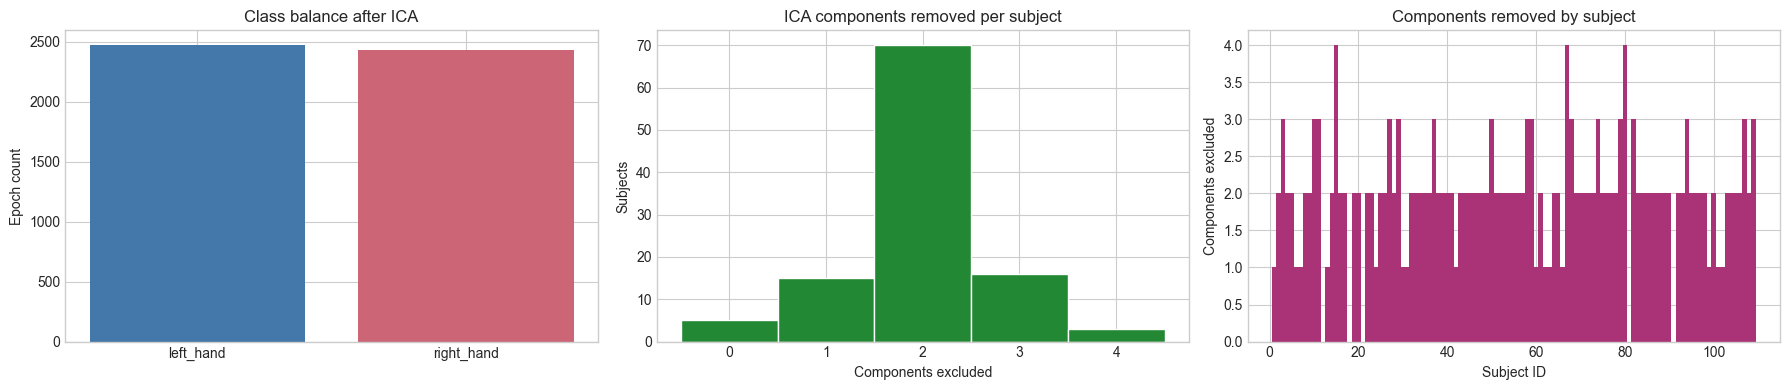

ICA summary: 2.0 +/- 0.8 components removed (range: 0-4)


In [4]:
ica_df = dataset["ica_summary"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Class balance
class_counts = (
    pd.Series(dataset["y"])
    .map({0: "left_hand", 1: "right_hand"})
    .value_counts()
    .sort_index()
)
axes[0].bar(class_counts.index, class_counts.values, color=["#4477AA", "#CC6677"])
axes[0].set_title("Class balance after ICA")
axes[0].set_ylabel("Epoch count")

# ICA components removed per subject
axes[1].hist(
    ica_df["n_excluded"],
    bins=np.arange(-0.5, ica_df["n_excluded"].max() + 1.5, 1),
    color="#228833",
    edgecolor="white",
)
axes[1].set_title("ICA components removed per subject")
axes[1].set_xlabel("Components excluded")
axes[1].set_ylabel("Subjects")

# Components removed vs subject
axes[2].bar(ica_df["subject"], ica_df["n_excluded"], color="#AA3377", width=1.0)
axes[2].set_title("Components removed by subject")
axes[2].set_xlabel("Subject ID")
axes[2].set_ylabel("Components excluded")

plt.tight_layout()
plt.show()

print(
    f"ICA summary: {ica_df['n_excluded'].mean():.1f} +/- {ica_df['n_excluded'].std():.1f} "
    f"components removed (range: {ica_df['n_excluded'].min()}-{ica_df['n_excluded'].max()})"
)

## Training helpers

In [5]:
def make_group_split(groups: np.ndarray, seed: int) -> dict:
    index = np.arange(len(groups))
    outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    train_val_idx, test_idx = next(outer.split(index, groups=groups))
    inner = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=seed + 100)
    inner_train_rel, inner_val_rel = next(
        inner.split(np.arange(len(train_val_idx)), groups=groups[train_val_idx])
    )
    return {
        "train": train_val_idx[inner_train_rel],
        "val": train_val_idx[inner_val_rel],
        "test": test_idx,
    }


def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    return DataLoader(
        TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=False,
    )


def unpack_logits(logits):
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    while logits.ndim > 2 and logits.shape[-1] == 1:
        logits = logits.squeeze(-1)
    if logits.ndim > 2:
        logits = logits.mean(dim=tuple(range(2, logits.ndim)))
    return logits


@torch.no_grad()
def predict_torch(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    preds = []
    for batch_X, _ in loader:
        batch_X = batch_X.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


def build_model(
    model_name: str, n_chans: int, n_times: int, sfreq: float, chs_info: list[dict]
) -> nn.Module:
    common = dict(
        n_chans=n_chans, n_times=n_times, n_outputs=2, sfreq=sfreq, chs_info=chs_info
    )
    if model_name == "EEGSimpleConv":
        return EEGSimpleConv(**common).to(DEVICE)
    if model_name == "EEGInceptionMI":
        return EEGInceptionMI(**common).to(DEVICE)
    if model_name == "EEGSym":
        return EEGSym(**common, scales_time=(525, 275, 125)).to(DEVICE)
    if model_name == "MSVTNet":
        return MSVTNet(**common).to(DEVICE)
    if model_name == "EEGNeX":
        return EEGNeX(**common).to(DEVICE)
    if model_name == "CTNet":
        return CTNet(**common).to(DEVICE)
    raise KeyError(model_name)


def run_model_once(model_name, X, y, groups, chs_info, sfreq, seed):
    split = make_group_split(groups, seed)
    X_train, y_train = X[split["train"]], y[split["train"]]
    X_val, y_val = X[split["val"]], y[split["val"]]
    X_test, y_test = X[split["test"]], y[split["test"]]

    train_loader = make_loader(X_train, y_train, shuffle=True)
    val_loader = make_loader(X_val, y_val, shuffle=False)
    test_loader = make_loader(X_test, y_test, shuffle=False)

    set_seed(seed)
    model = build_model(model_name, X.shape[1], X.shape[2], sfreq, chs_info)
    optimizer = optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    criterion = nn.CrossEntropyLoss()
    best_state = None
    best_val_bal = -np.inf
    best_epoch = 0
    patience_counter = 0
    start = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = unpack_logits(model(batch_X))
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

        val_pred = predict_torch(model, val_loader)
        val_bal = balanced_accuracy_score(y_val, val_pred)
        if val_bal > best_val_bal + 1e-4:
            best_val_bal = val_bal
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    test_pred = predict_torch(model, test_loader)
    return {
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "val_balanced_accuracy": best_val_bal,
        "best_epoch": best_epoch,
        "train_time_s": time.perf_counter() - start,
    }

## Run benchmarks (6 models x 3 channel configs x 5 splits)

In [6]:
all_rows = []
total_runs = len(CHANNEL_OPTIONS) * N_SPLITS * len(MODEL_NAMES)
pbar = tqdm(total=total_runs, desc="Benchmarking")

for subset_name, subset_channels in CHANNEL_OPTIONS.items():
    X_sub, names_sub, chs_sub = select_channels(
        dataset["X"], dataset["channel_names"], dataset["chs_info"], subset_channels
    )
    for split_idx in range(N_SPLITS):
        seed = SEED + split_idx
        for model_name in MODEL_NAMES:
            pbar.set_postfix_str(f"{model_name} | {subset_name} | split {split_idx}")
            result = run_model_once(
                model_name=model_name,
                X=X_sub,
                y=dataset["y"],
                groups=dataset["groups"],
                chs_info=chs_sub,
                sfreq=dataset["sfreq"],
                seed=seed,
            )
            result.update(
                {
                    "model": model_name,
                    "channel_subset": subset_name,
                    "n_channels": X_sub.shape[1],
                    "split": split_idx,
                }
            )
            all_rows.append(result)
            pbar.update(1)

pbar.close()
results_df = pd.DataFrame(all_rows)
print(f"Collected {len(results_df)} results.")
display(results_df.head(10))

Benchmarking:   1%|          | 1/90 [00:06<09:32,  6.44s/it, EEGInceptionMI | all_64 | split 0]/home/aniruddham/code/project/.venv/lib/python3.14/site-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv2d(
Benchmarking:   3%|▎         | 3/90 [02:29<1:27:18, 60.21s/it, MSVTNet | all_64 | split 0]     /home/aniruddham/code/project/.venv/lib/python3.14/site-packages/braindecode/models/msvtnet.py:340: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.trans = nn.TransformerEncoder(
Benchmarking:  10%|█         | 9/90 [06:56<1:29:01, 65.95s/it, MSVTNet | all_64 | split 1]     /home/aniruddham/code/project/.venv/lib/python3.14/site-packages/braindecode/models/msvtnet.py:340: UserWarning: enable_nested_tensor

Collected 90 results.


,test_balanced_accuracy,val_balanced_accuracy,best_epoch,train_time_s,model,channel_subset,n_channels,split
0,0.545176,0.635967,5,4.637209,EEGSimpleConv,all_64,64,0
1,0.556601,0.638873,7,39.005273,EEGInceptionMI,all_64,64,0
2,0.503951,0.524746,5,91.914048,EEGSym,all_64,64,0
3,0.574926,0.630889,12,23.308080,MSVTNet,all_64,64,0
4,0.552356,0.678119,10,27.629601,EEGNeX,all_64,64,0
5,0.577141,0.648172,12,20.261774,CTNet,all_64,64,0
6,0.612804,0.600979,3,2.580051,EEGSimpleConv,all_64,64,1
7,0.605147,0.586624,5,31.257343,EEGInceptionMI,all_64,64,1
8,0.650432,0.607192,12,141.514612,EEGSym,all_64,64,1
9,0.620404,0.607584,12,23.065078,MSVTNet,all_64,64,1


## Summary table (mean +/- std across 5 splits)

In [7]:
summary = (
    results_df.groupby(["model", "channel_subset", "n_channels"], as_index=False)
    .agg(
        mean_bal_acc=("test_balanced_accuracy", "mean"),
        std_bal_acc=("test_balanced_accuracy", "std"),
        mean_val_acc=("val_balanced_accuracy", "mean"),
        mean_train_time_s=("train_time_s", "mean"),
        mean_best_epoch=("best_epoch", "mean"),
    )
    .sort_values("mean_bal_acc", ascending=False)
    .reset_index(drop=True)
)
summary["bal_acc_str"] = summary.apply(
    lambda r: f"{r['mean_bal_acc']:.4f} +/- {r['std_bal_acc']:.4f}", axis=1
)
display(summary)

,model,channel_subset,n_channels,mean_bal_acc,std_bal_acc,mean_val_acc,mean_train_time_s,mean_best_epoch,bal_acc_str
0,EEGSym,all_64,64,0.618608,0.066728,0.614161,125.883211,9.2,0.6186 +/- 0.0667
1,EEGNeX,all_64,64,0.615367,0.037491,0.619935,22.277597,7.2,0.6154 +/- 0.0375
2,EEGNeX,sensorimotor_9,9,0.602889,0.023212,0.614895,5.195654,7.0,0.6029 +/- 0.0232
3,EEGNeX,sensorimotor_17,17,0.597988,0.028172,0.608171,6.266104,6.0,0.5980 +/- 0.0282
4,EEGInceptionMI,all_64,64,0.597527,0.026500,0.602460,31.921768,5.2,0.5975 +/- 0.0265
5,EEGInceptionMI,sensorimotor_9,9,0.594742,0.021428,0.598452,24.710685,3.4,0.5947 +/- 0.0214
6,EEGSimpleConv,all_64,64,0.591688,0.030620,0.600681,3.122599,3.8,0.5917 +/- 0.0306
7,EEGSimpleConv,sensorimotor_9,9,0.589657,0.027638,0.602819,2.472637,4.2,0.5897 +/- 0.0276
8,EEGSimpleConv,sensorimotor_17,17,0.588162,0.030243,0.587791,2.324299,2.8,0.5882 +/- 0.0302
9,CTNet,sensorimotor_9,9,0.588040,0.025668,0.596865,12.533315,8.6,0.5880 +/- 0.0257


## Model comparison (aggregated across all channel configs)

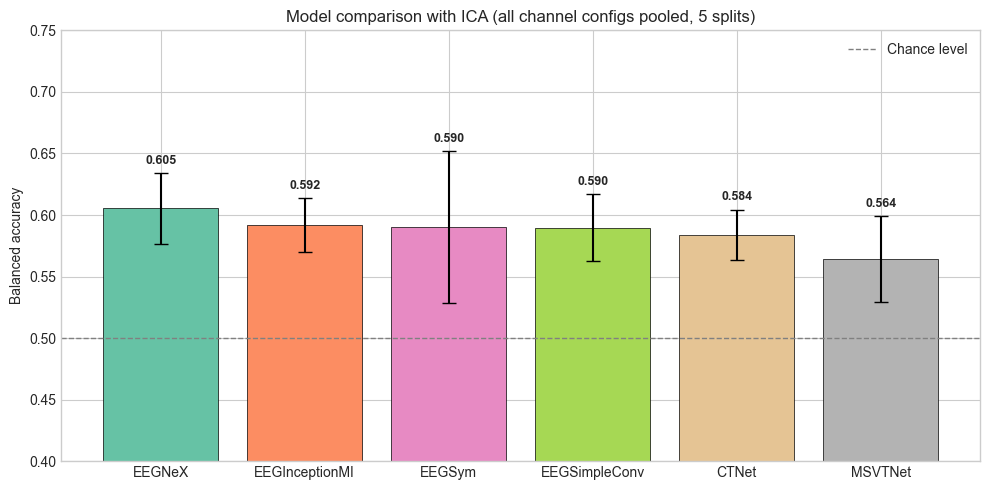

In [8]:
model_summary = (
    results_df.groupby("model", as_index=False)
    .agg(
        mean_bal_acc=("test_balanced_accuracy", "mean"),
        std_bal_acc=("test_balanced_accuracy", "std"),
        mean_train_time_s=("train_time_s", "mean"),
    )
    .sort_values("mean_bal_acc", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
models_sorted = model_summary["model"].tolist()
means = model_summary["mean_bal_acc"].tolist()
stds = model_summary["std_bal_acc"].tolist()
colors = plt.cm.Set2(np.linspace(0, 1, len(models_sorted)))
bars = ax.bar(
    models_sorted,
    means,
    yerr=stds,
    capsize=5,
    color=colors,
    edgecolor="black",
    linewidth=0.5,
)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="Chance level")
ax.set_ylabel("Balanced accuracy")
ax.set_title("Model comparison with ICA (all channel configs pooled, 5 splits)")
ax.set_ylim(0.40, 0.75)
ax.legend()
for bar, m, s in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + s + 0.005,
        f"{m:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
plt.tight_layout()
plt.show()

## Channel ablation study

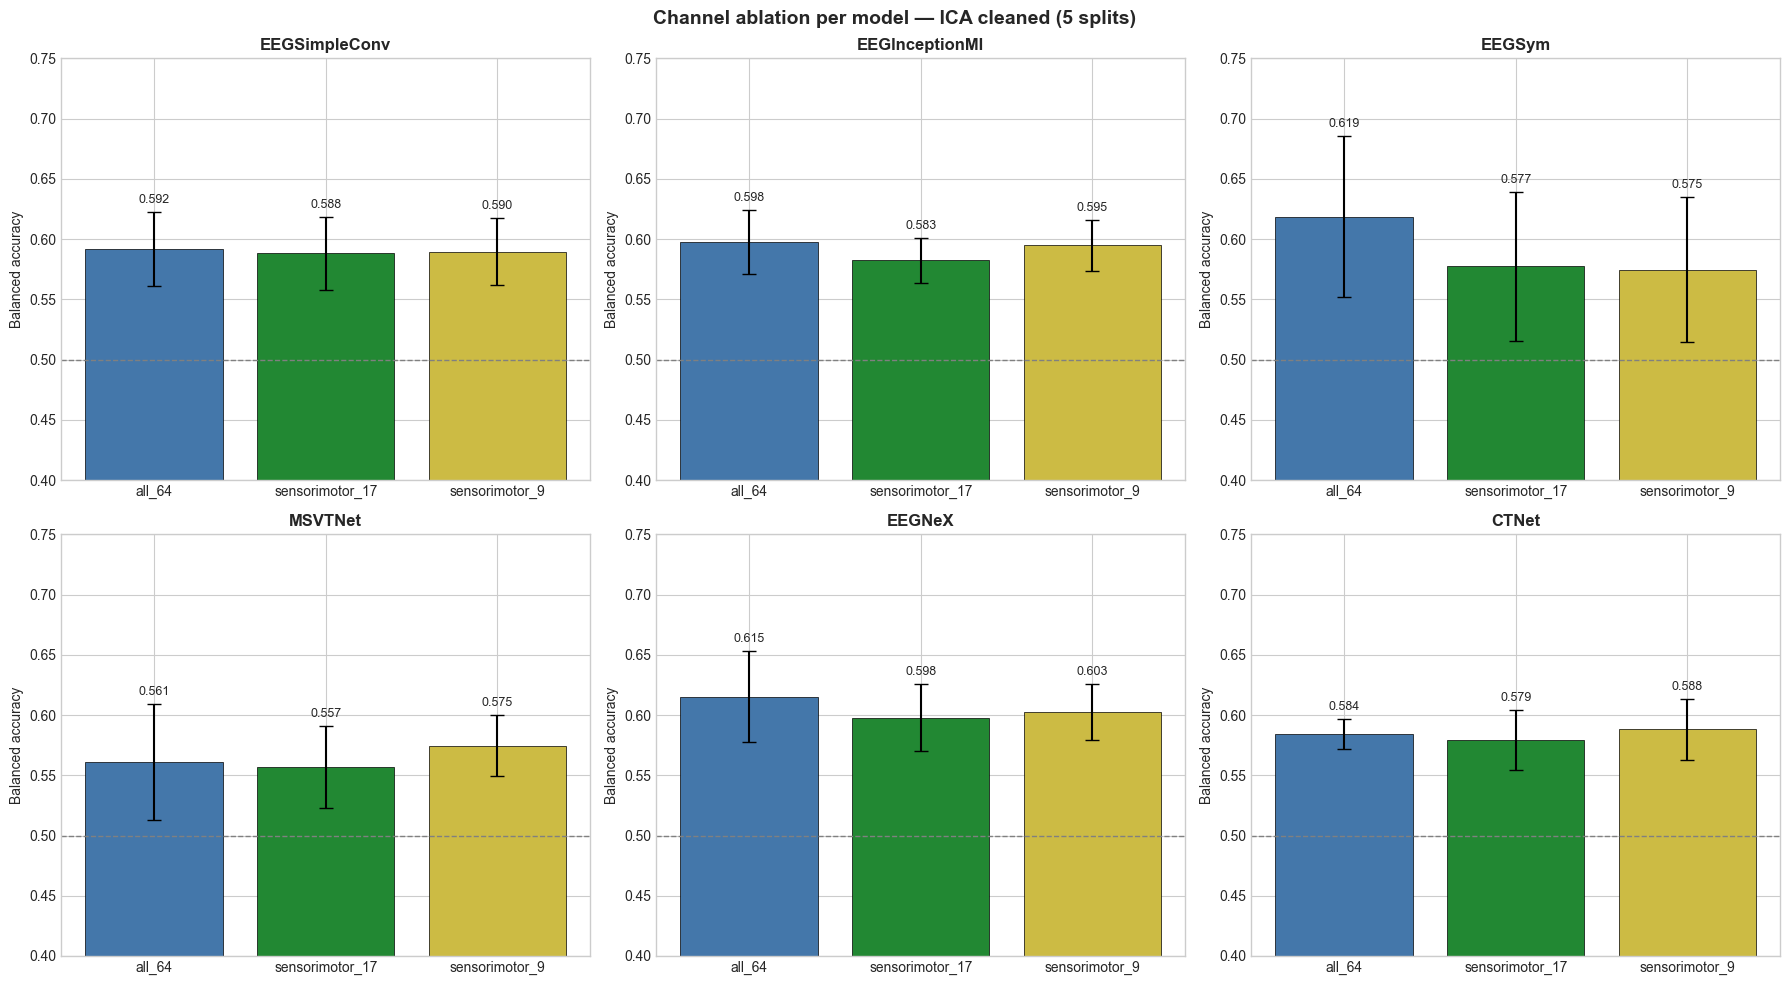

In [9]:
channel_order = ["all_64", "sensorimotor_17", "sensorimotor_9"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, model_name in enumerate(MODEL_NAMES):
    ax = axes[idx // 3, idx % 3]
    model_data = summary[summary["model"] == model_name].set_index("channel_subset")
    model_data = model_data.reindex(channel_order)
    bars = ax.bar(
        model_data.index,
        model_data["mean_bal_acc"],
        yerr=model_data["std_bal_acc"],
        capsize=5,
        color=["#4477AA", "#228833", "#CCBB44"],
        edgecolor="black",
        linewidth=0.5,
    )
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
    ax.set_title(model_name, fontweight="bold")
    ax.set_ylabel("Balanced accuracy")
    ax.set_ylim(0.40, 0.75)
    for bar, m, s in zip(bars, model_data["mean_bal_acc"], model_data["std_bal_acc"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + s + 0.005,
            f"{m:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )
plt.suptitle(
    "Channel ablation per model — ICA cleaned (5 splits)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

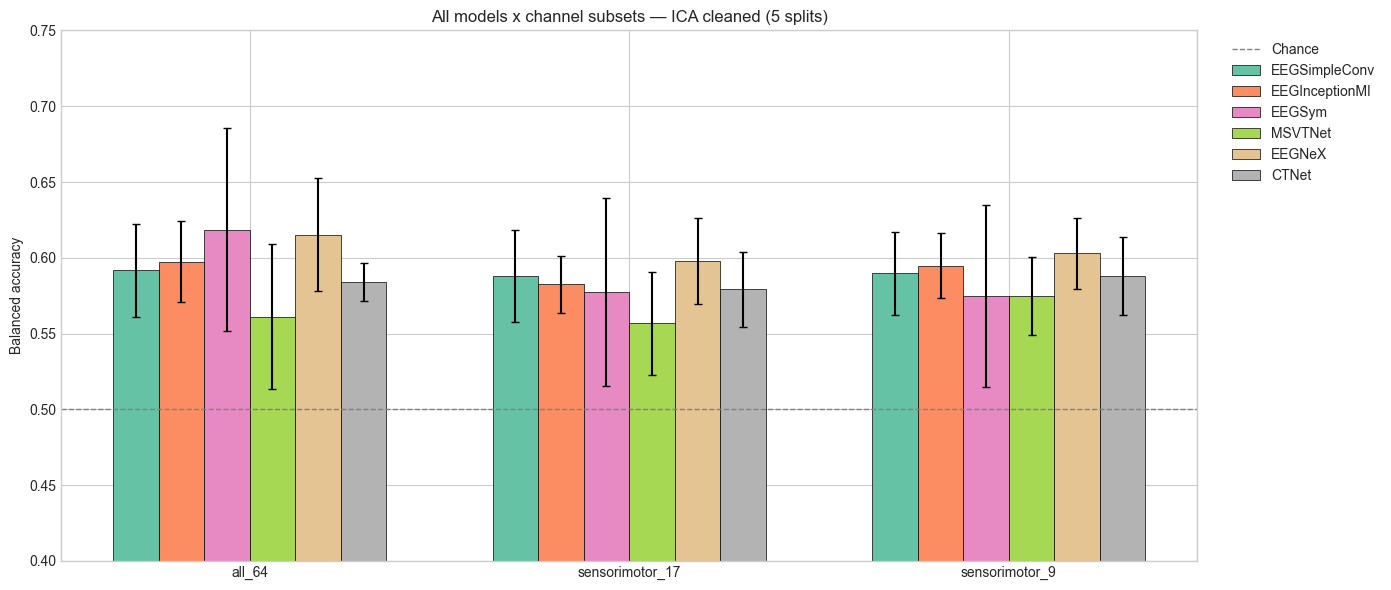

In [10]:
# Grouped bar chart: all models side-by-side for each channel config
fig, ax = plt.subplots(figsize=(14, 6))
n_models = len(MODEL_NAMES)
n_channels = len(channel_order)
x = np.arange(n_channels)
width = 0.12

for i, model_name in enumerate(MODEL_NAMES):
    model_data = (
        summary[summary["model"] == model_name]
        .set_index("channel_subset")
        .reindex(channel_order)
    )
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(
        x + offset,
        model_data["mean_bal_acc"],
        width,
        yerr=model_data["std_bal_acc"],
        label=model_name,
        color=colors[i],
        edgecolor="black",
        linewidth=0.5,
        capsize=3,
    )

ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="Chance")
ax.set_xticks(x)
ax.set_xticklabels(channel_order)
ax.set_ylabel("Balanced accuracy")
ax.set_title("All models x channel subsets — ICA cleaned (5 splits)")
ax.set_ylim(0.40, 0.75)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Training time comparison

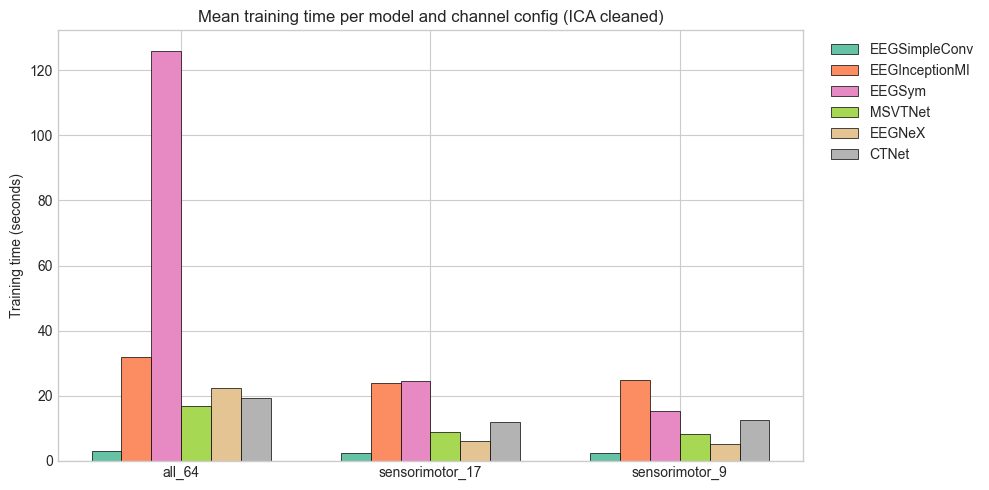

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
time_summary = results_df.groupby(["model", "channel_subset"], as_index=False).agg(
    mean_time=("train_time_s", "mean")
)

for i, model_name in enumerate(MODEL_NAMES):
    model_data = (
        time_summary[time_summary["model"] == model_name]
        .set_index("channel_subset")
        .reindex(channel_order)
    )
    offset = (i - n_models / 2 + 0.5) * width
    ax.bar(
        x + offset,
        model_data["mean_time"],
        width,
        label=model_name,
        color=colors[i],
        edgecolor="black",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(channel_order)
ax.set_ylabel("Training time (seconds)")
ax.set_title("Mean training time per model and channel config (ICA cleaned)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Per-split performance (box plots)

/tmp/ipykernel_557638/931201303.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_557638/931201303.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_557638/931201303.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


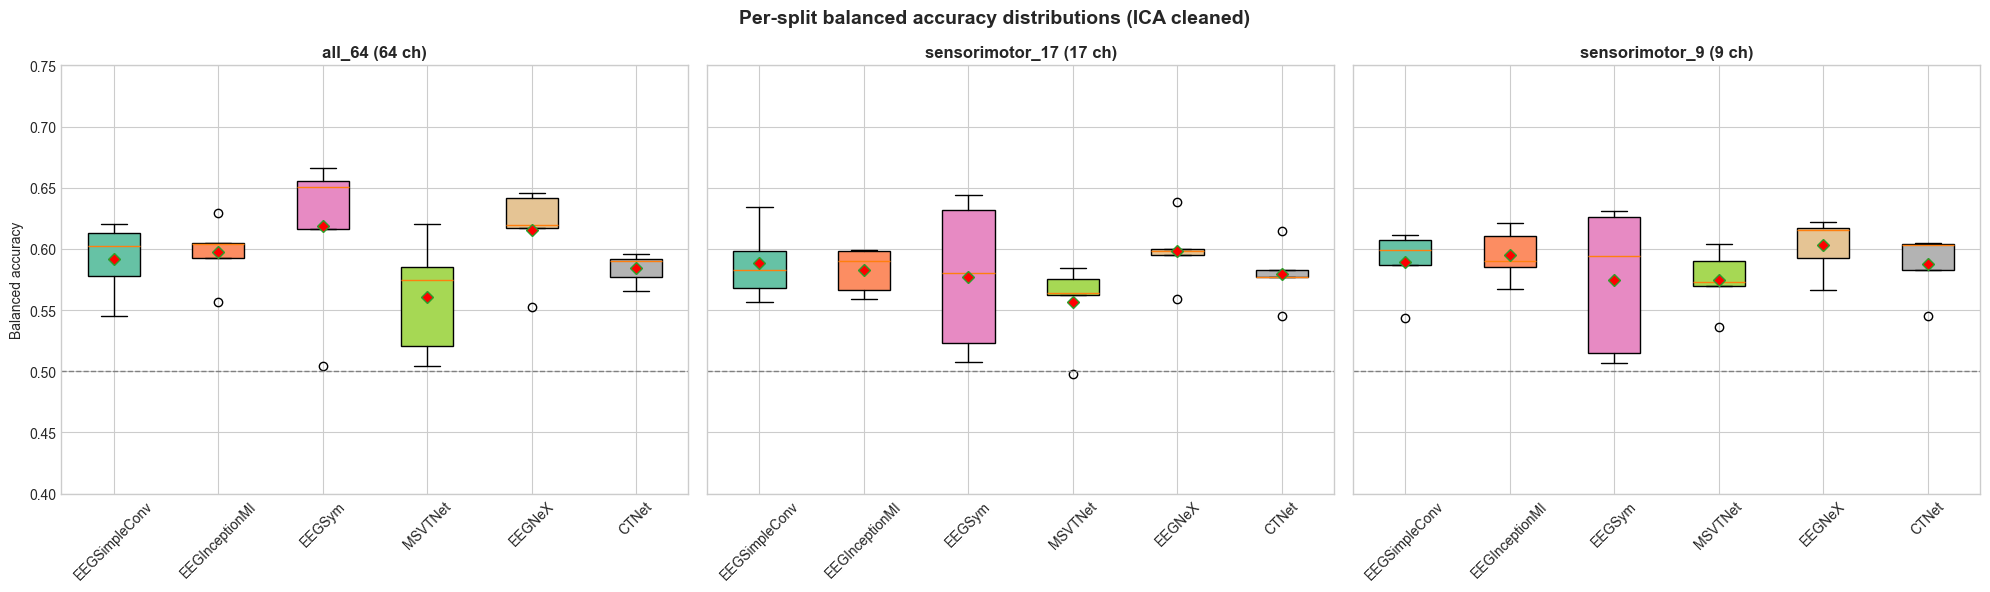

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for col_idx, ch_subset in enumerate(channel_order):
    ax = axes[col_idx]
    subset_df = results_df[results_df["channel_subset"] == ch_subset]
    data_by_model = [
        subset_df[subset_df["model"] == m]["test_balanced_accuracy"].values
        for m in MODEL_NAMES
    ]
    bp = ax.boxplot(
        data_by_model,
        labels=MODEL_NAMES,
        patch_artist=True,
        showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="red", markersize=6),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
    ax.set_title(
        f"{ch_subset} ({subset_df['n_channels'].iloc[0]} ch)", fontweight="bold"
    )
    ax.set_ylabel("Balanced accuracy" if col_idx == 0 else "")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0.40, 0.75)

plt.suptitle(
    "Per-split balanced accuracy distributions (ICA cleaned)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Accuracy vs. training time (Pareto view)

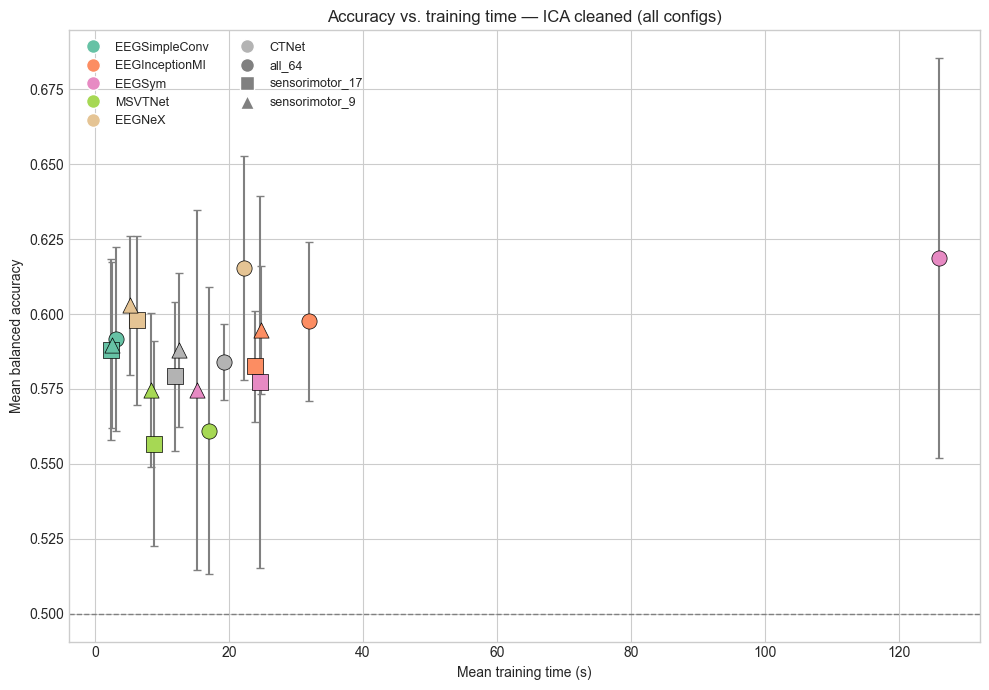

In [13]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 7))
markers = {"all_64": "o", "sensorimotor_17": "s", "sensorimotor_9": "^"}

for i, model_name in enumerate(MODEL_NAMES):
    for ch_sub in channel_order:
        row = summary[
            (summary["model"] == model_name) & (summary["channel_subset"] == ch_sub)
        ]
        if row.empty:
            continue
        row = row.iloc[0]
        ax.scatter(
            row["mean_train_time_s"],
            row["mean_bal_acc"],
            s=120,
            c=[colors[i]],
            marker=markers[ch_sub],
            edgecolors="black",
            linewidths=0.5,
            zorder=5,
        )
        ax.errorbar(
            row["mean_train_time_s"],
            row["mean_bal_acc"],
            yerr=row["std_bal_acc"],
            fmt="none",
            ecolor="grey",
            capsize=3,
            zorder=4,
        )

model_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colors[i],
        markersize=10,
        label=m,
    )
    for i, m in enumerate(MODEL_NAMES)
]
ch_handles = [
    Line2D(
        [0],
        [0],
        marker=markers[ch],
        color="w",
        markerfacecolor="grey",
        markersize=10,
        label=ch,
    )
    for ch in channel_order
]
ax.legend(handles=model_handles + ch_handles, loc="upper left", ncol=2, fontsize=9)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Mean training time (s)")
ax.set_ylabel("Mean balanced accuracy")
ax.set_title("Accuracy vs. training time — ICA cleaned (all configs)")
plt.tight_layout()
plt.show()

## Heatmap: model x channel subset

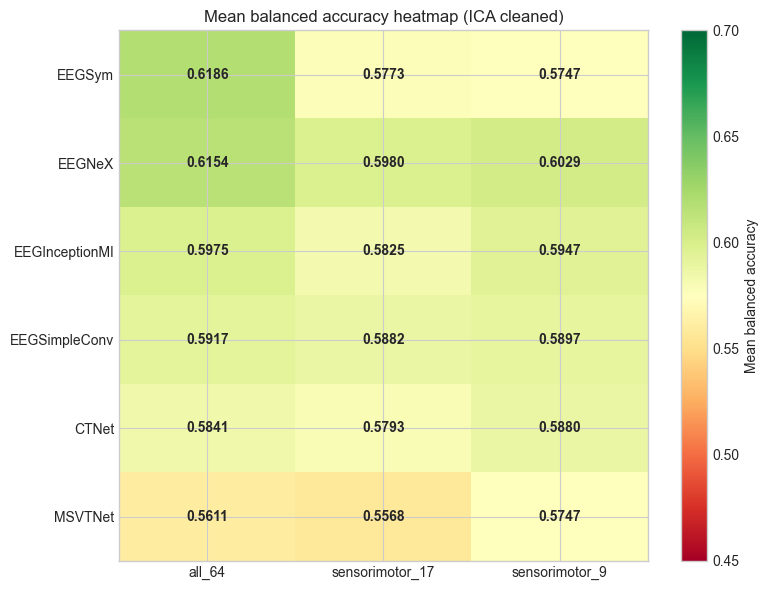

In [14]:
pivot = summary.pivot(index="model", columns="channel_subset", values="mean_bal_acc")
pivot = pivot.reindex(columns=channel_order)
pivot = pivot.reindex(
    summary.drop_duplicates("model").sort_values("mean_bal_acc", ascending=False)[
        "model"
    ]
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=0.45, vmax=0.70)
ax.set_xticks(range(len(channel_order)))
ax.set_xticklabels(channel_order)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(len(pivot.index)):
    for j in range(len(channel_order)):
        val = pivot.iloc[i, j]
        ax.text(
            j, i, f"{val:.4f}", ha="center", va="center", fontsize=10, fontweight="bold"
        )
plt.colorbar(im, ax=ax, label="Mean balanced accuracy")
ax.set_title("Mean balanced accuracy heatmap (ICA cleaned)")
plt.tight_layout()
plt.show()

## Best configuration

In [15]:
best = summary.iloc[0]
print("=" * 60)
print("BEST CONFIGURATION (ICA cleaned)")
print("=" * 60)
print(f"  Model:            {best['model']}")
print(f"  Channel subset:   {best['channel_subset']} ({best['n_channels']} channels)")
print(f"  Balanced acc:     {best['mean_bal_acc']:.4f} +/- {best['std_bal_acc']:.4f}")
print(f"  Val balanced acc: {best['mean_val_acc']:.4f}")
print(f"  Mean train time:  {best['mean_train_time_s']:.1f} s")
print(f"  Mean best epoch:  {best['mean_best_epoch']:.1f}")
print("=" * 60)

print("\nTop 5 configurations:")
display(
    summary.head(5)[
        ["model", "channel_subset", "n_channels", "bal_acc_str", "mean_train_time_s"]
    ]
)

print("\nBottom 5 configurations:")
display(
    summary.tail(5)[
        ["model", "channel_subset", "n_channels", "bal_acc_str", "mean_train_time_s"]
    ]
)

BEST CONFIGURATION (ICA cleaned)
  Model:            EEGSym
  Channel subset:   all_64 (64 channels)
  Balanced acc:     0.6186 +/- 0.0667
  Val balanced acc: 0.6142
  Mean train time:  125.9 s
  Mean best epoch:  9.2

Top 5 configurations:


,model,channel_subset,n_channels,bal_acc_str,mean_train_time_s
0,EEGSym,all_64,64,0.6186 +/- 0.0667,125.883211
1,EEGNeX,all_64,64,0.6154 +/- 0.0375,22.277597
2,EEGNeX,sensorimotor_9,9,0.6029 +/- 0.0232,5.195654
3,EEGNeX,sensorimotor_17,17,0.5980 +/- 0.0282,6.266104
4,EEGInceptionMI,all_64,64,0.5975 +/- 0.0265,31.921768



Bottom 5 configurations:


,model,channel_subset,n_channels,bal_acc_str,mean_train_time_s
13,EEGSym,sensorimotor_17,17,0.5773 +/- 0.0621,24.692519
14,MSVTNet,sensorimotor_9,9,0.5747 +/- 0.0256,8.405014
15,EEGSym,sensorimotor_9,9,0.5747 +/- 0.0599,15.258838
16,MSVTNet,all_64,64,0.5611 +/- 0.0478,16.982406
17,MSVTNet,sensorimotor_17,17,0.5568 +/- 0.0341,8.774732
